# Intro notebook: building rs-fMRI and DTI connectivity matrices from electrode coordinates

This notebook is a **starter template** for an introductory student.  It shows how to:

1. Start with electrode locations in **MNI space** (`N x 3` NumPy array).
2. Build a **resting-state fMRI connectivity matrix** by extracting BOLD time series around each location.
3. Build a **DTI / structural connectivity matrix** in two practical ways:
   - **Option A (best when you have tractography):** create spherical ROIs around electrode locations and count streamlines between them.
   - **Option B (best when you only have an atlas-level structural connectome):** map each coordinate to an atlas parcel and lift parcel-level connectivity up to the electrode level.

The resting-state section is designed to be close to runnable on open datasets using `nilearn`.  
The DTI section is written as a **clear starter workflow** with code you can adapt once you have diffusion data or a tractogram available.

---
## Expected input

You should already have electrode coordinates in MNI space:

```python
mni_coords.shape == (N, 3)
```

where each row is `[x, y, z]` in millimeters.


In [8]:
# If needed, uncomment and run:
!pip install nilearn nibabel pandas matplotlib scipy dipy


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

import nibabel as nib
from nilearn import datasets, image, plotting
from nilearn.maskers import NiftiSpheresMasker
from nilearn.connectome import ConnectivityMeasure
from scipy.spatial.distance import cdist

# Make plots a bit larger
plt.rcParams["figure.figsize"] = (8, 6)

## 1. Define electrode coordinates in MNI space

Replace the example coordinates below with your own array.

A good beginner habit is to also keep a list of electrode names in the same order.


## 4. Extract rs-fMRI time series at the electrode coordinates

`NiftiSpheresMasker` creates a sphere around each coordinate and extracts a time series from each sphere.

Important beginner parameters:
- `radius`: sphere radius in mm
- `t_r`: repetition time of the fMRI sequence
- `low_pass` / `high_pass`: optional temporal filtering
- `standardize`: z-score each extracted time series


In [10]:
# ---------------------------
# USER INPUT
# ---------------------------

import numpy as np
import pandas as pd
import os

# Folder containing your 5 electrode .npy files
folder = r"C:\Users\brael\OneDrive\Desktop\Research\electrode_connectivity\data"

# Replace the hardcoded array with this line:
# Stack all the coordinates into a single 2D array (5 electrodes × 3 coordinates)
mni_coords = np.vstack([np.load(os.path.join(folder, f)) for f in sorted(os.listdir(folder)) if f.endswith(".npy")])

# Keep the rest exactly the same
electrode_names = [f"E{i+1}" for i in range(len(mni_coords))]

print("mni_coords shape:", mni_coords.shape)
print(pd.DataFrame(mni_coords, columns=["x", "y", "z"], index=electrode_names))

mni_coords shape: (576, 3)
          x      y      z
E1   -38.79  51.43  47.05
E2   -43.98  42.16  46.89
E3   -48.86  33.30  45.33
E4   -52.44  24.40  43.61
E5   -54.86  15.87  40.38
...     ...    ...    ...
E572 -20.89  -5.00  11.87
E573 -23.75  -4.34  14.60
E574 -26.98  -4.06  16.09
E575 -30.08  -4.74  18.71
E576 -33.00  -3.67  20.55

[576 rows x 3 columns]


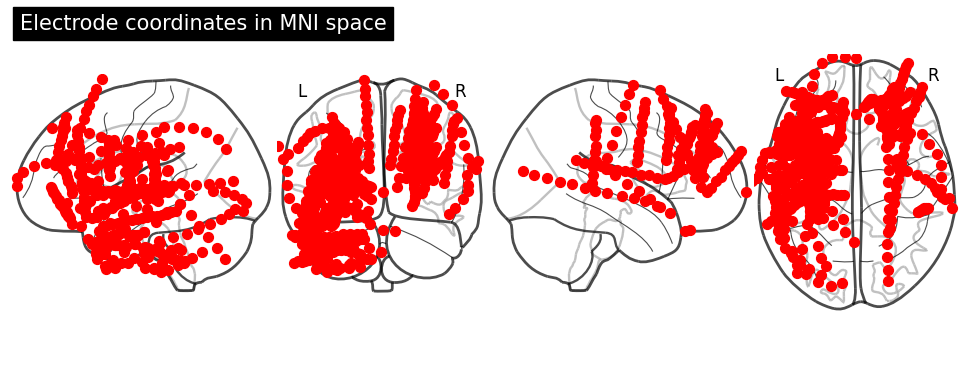

In [11]:
from nilearn import plotting

# Plot just the electrode points on the MNI template
display = plotting.plot_glass_brain(
    None,  # no background image
    display_mode='lyrz',  # shows all views
    title='Electrode coordinates in MNI space'
)

# Add your electrodes manually
for coord in mni_coords:
    display.add_markers([coord], marker_color='red', marker_size=50)

plotting.show()

## 2. A few helper functions

These are useful for plotting and saving connectivity matrices.


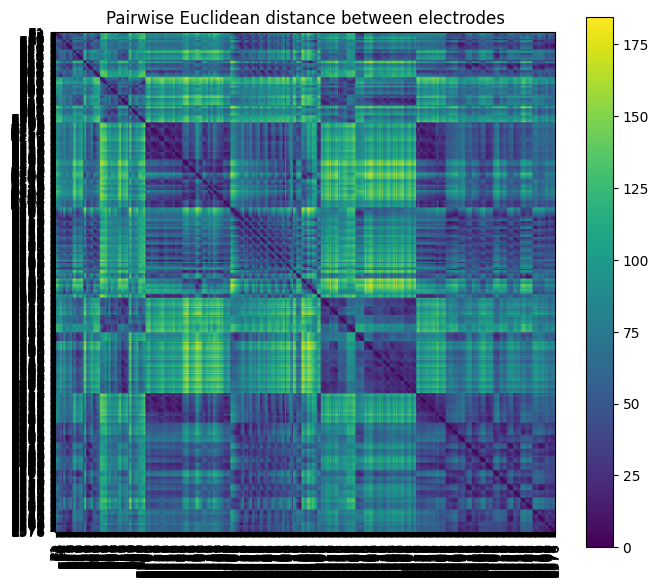

In [12]:
from scipy.spatial.distance import cdist
import matplotlib.pyplot as plt
import pandas as pd

def plot_matrix(mat, labels=None, title="Connectivity matrix", cmap="coolwarm", vmin=None, vmax=None):
    plt.figure(figsize=(7, 6))
    plt.imshow(mat, cmap=cmap, vmin=vmin, vmax=vmax)
    plt.colorbar()
    if labels is not None:
        plt.xticks(range(len(labels)), labels, rotation=90)
        plt.yticks(range(len(labels)), labels)
    plt.title(title)
    plt.tight_layout()
    plt.show()

def save_matrix_csv(mat, labels, out_file):
    df = pd.DataFrame(mat, index=labels, columns=labels)
    df.to_csv(out_file)
    print(f"Saved: {out_file}")

def pairwise_distance_matrix(coords):
    return cdist(coords, coords, metric="euclidean")

dist_mat = pairwise_distance_matrix(mni_coords)
plot_matrix(dist_mat, labels=electrode_names, title="Pairwise Euclidean distance between electrodes", cmap="viridis")

# Part I: Resting-state fMRI connectivity

The basic idea is:

1. Load a resting-state fMRI image.
2. Extract one time series per electrode location using small **spheres** around each MNI coordinate.
3. Correlate the extracted time series to get an `N x N` functional connectivity matrix.

For a starter example, we use a small open dataset that `nilearn` can fetch automatically.  
Later, you can replace that dataset with HCP or another source.


## 3. Fetch a sample resting-state dataset

For an introductory notebook, `nilearn.datasets.fetch_adhd()` is a simple public example.
If you later switch to HCP or another dataset, the rest of the code is very similar: the main change is the path to the 4D fMRI image and its repetition time (`t_r`).


In [13]:
from nilearn import image
from nilearn.maskers import NiftiMasker

func_file = r"C:\Users\brael\OneDrive\Desktop\Research\rfMRI_REST_mean.nii.gz"
func_img = image.load_img(func_file)
print("Loaded fMRI image shape:", func_img.shape)

Loaded fMRI image shape: (91, 109, 91)


In [ ]:
# Load / lightly clean the image
func_img = image.load_img(func_file)

# Choose a sphere radius in millimeters
sphere_radius_mm = 6

# NOTE:
# t_r here is a placeholder/example. Replace with the true TR for your dataset if known.
masker = NiftiSpheresMasker(
    seeds=mni_coords,
    radius=sphere_radius_mm,
    detrend=True,
    standardize="zscore_sample",
    low_pass=0.08,
    high_pass=0.01,
    t_r=2.0,   # replace with the correct TR for your dataset
)

# print("Extracted time series shape:", timeseries.shape)
# shape = (n_timepoints, n_electrodes)

NameError: name 'timeseries' is not defined

In [ ]:
# Inspect the first few time points
ts_df = pd.DataFrame(timeseries[:, :min(5, timeseries.shape[1])], columns=electrode_names[:min(5, len(electrode_names))])
ts_df.head()

NameError: name 'timeseries' is not defined

C:\Users\brael\AppData\Local\Temp\ipykernel_24016\4152949321.py:3: FutureWarning: The default strategy for standardize is currently 'zscore' which incorrectly uses population std to calculate sample zscores. The new strategy 'zscore_sample' corrects this behavior by using the sample std. In release 0.14.0, the default strategy will be replaced by the new strategy, the 'zscore' option will be removed. and using standardize=True will fall back to 'zscore_sample'.To avoid this warning, please use 'zscore_sample' instead.
  fmri_conn = corr_measure.fit_transform([timeseries])[0]


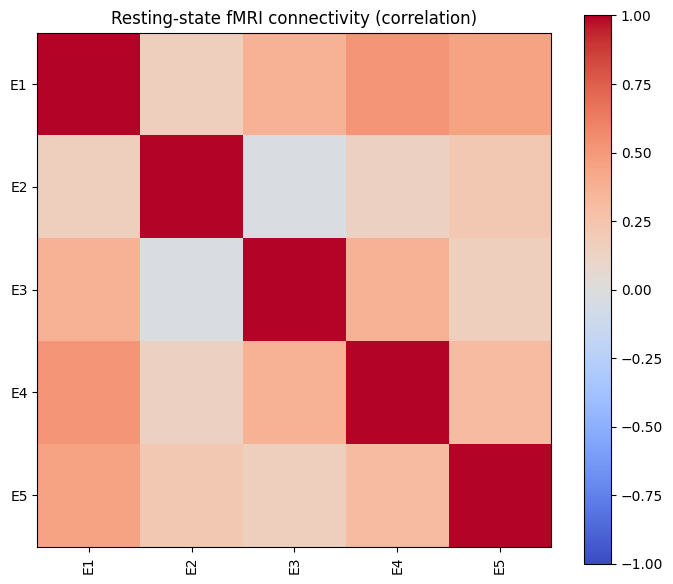

In [ ]:
# Compute an electrode-by-electrode correlation matrix
corr_measure = ConnectivityMeasure(kind="correlation")
fmri_conn = corr_measure.fit_transform([timeseries])[0]

plot_matrix(
    fmri_conn,
    labels=electrode_names,
    title="Resting-state fMRI connectivity (correlation)",
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

In [ ]:
# Save the rs-fMRI matrix
out_dir = Path("connectivity_outputs")
out_dir.mkdir(exist_ok=True)

save_matrix_csv(fmri_conn, electrode_names, out_dir / "rsfmri_connectivity.csv")

Saved: connectivity_outputs\rsfmri_connectivity.csv


## 5. Notes for switching to HCP or another resting-state dataset

Once you have a 4D resting-state image in MNI space, the main changes are usually just:

```python
func_img = image.load_img("path/to/your_rest_bold.nii.gz")
masker = NiftiSpheresMasker(
    seeds=mni_coords,
    radius=6,
    detrend=True,
    standardize="zscore_sample",
    low_pass=0.08,
    high_pass=0.01,
    t_r=YOUR_TR_HERE,
)
timeseries = masker.fit_transform(func_img)
fmri_conn = ConnectivityMeasure(kind="correlation").fit_transform([timeseries])[0]
```

If your fMRI is **not** in MNI space, you have two choices:
1. transform the electrode coordinates from MNI into the subject's fMRI space, or
2. register the fMRI into MNI space first.


# Part II: DTI / structural connectivity

Structural connectivity is trickier than rs-fMRI because there is not usually a single 4D image from which we can directly extract a time series.

A practical beginner view:

- **rs-fMRI matrix** = similarity of BOLD time series between locations.
- **DTI matrix** = how strongly white matter pathways connect those locations.

There are two common ways to get an electrode-level DTI matrix.


## Option A: Build the matrix from a tractogram

This is the most direct way if you already have:
- a diffusion-space or MNI-space **reference image**
- a **tractogram** (`.trk`, `.tck`, etc.)
- electrode coordinates in the **same space** as that reference image

The idea is:

1. Make a small spherical ROI around each electrode.
2. Label each sphere with a unique integer.
3. Count streamlines connecting ROI `i` to ROI `j`.

This gives an `N x N` structural connectivity matrix.


In [ ]:
# DTI OPTION A
# This cell is a template. It will work once you provide:
#   1) a reference image
#   2) a tractogram
#   3) coordinates in the same space as the reference image

from scipy.spatial.distance import cdist

def create_spherical_roi_label_image(mni_coords, reference_img, radius_mm=5):
    """Create a 3D integer label image with one spherical ROI per coordinate.

    Background = 0
    Electrode 1 = label 1
    Electrode 2 = label 2
    ...
    """
    shape = reference_img.shape[:3]
    affine = reference_img.affine
    inv_affine = np.linalg.inv(affine)

    # Grid of voxel coordinates
    i, j, k = np.indices(shape)
    ijk = np.column_stack([i.ravel(), j.ravel(), k.ravel()])

    # Convert voxel centers to world (MNI) coordinates
    xyz = nib.affines.apply_affine(affine, ijk)

    label_data = np.zeros(shape, dtype=np.int32)

    for idx, coord in enumerate(mni_coords, start=1):
        d = np.linalg.norm(xyz - coord, axis=1)
        mask = (d <= radius_mm).reshape(shape)

        # Assign label idx to that sphere.
        # If spheres overlap, later spheres overwrite earlier ones.
        label_data[mask] = idx

    return nib.Nifti1Image(label_data, affine)

# Example usage (replace these paths with real files):
# reference_img = nib.load("reference_in_same_space_as_coords.nii.gz")
# roi_img = create_spherical_roi_label_image(mni_coords, reference_img, radius_mm=5)

# plotting.plot_roi(roi_img, bg_img=reference_img, title="Electrode ROIs")
# plotting.show()

In [ ]:
# DTI OPTION A continued:
# Once you have a tractogram in the SAME space as the ROI label image,
# you can count streamlines between labeled ROIs.

# from dipy.io.streamline import load_trk
# from dipy.tracking.utils import connectivity_matrix

# tractogram = load_trk("tractogram.trk", "same")
# streamlines = tractogram.streamlines

# label_volume = roi_img.get_fdata().astype(np.int32)

# conn_full = connectivity_matrix(
#     streamlines,
#     affine=reference_img.affine,
#     label_volume=label_volume,
#     symmetric=True,
#     return_mapping=False,
#     mapping_as_streamlines=False
# )

# connectivity_matrix returns a matrix that includes label 0 (background),
# so electrode labels 1..N are in rows/cols 1..N:
# dti_conn = conn_full[1:len(mni_coords)+1, 1:len(mni_coords)+1]

# plot_matrix(dti_conn, labels=electrode_names, title="DTI connectivity from tractography", cmap="viridis")
# save_matrix_csv(dti_conn, electrode_names, out_dir / "dti_connectivity_from_tractography.csv")

### Important note about spaces

For DTI, this is the most common beginner pitfall:

Your coordinates and your tractogram must be in the **same space**.

That means one of the following must be true:
- both are already in **MNI space**, or
- both are in the **subject's native diffusion / anatomical space**

If your electrode coordinates are in MNI but your tractogram is in subject space, you must transform one into the space of the other before counting streamlines.


## Option B: Map coordinates to an atlas and use an atlas-level structural connectome

Sometimes you do **not** have tractography for the exact same subjects, but you do have:
- an atlas image in MNI space
- a parcel-by-parcel structural connectivity matrix from another source
- electrode coordinates in MNI space

Then you can:
1. assign each electrode to an atlas parcel,
2. look up the structural connectivity between those parcels,
3. build an electrode-by-electrode matrix by indexing into the parcel matrix.

This is often a useful first pass for teaching and prototyping.


In [ ]:
from nilearn import datasets

# Fetch Harvard-Oxford cortical atlas
atlas = datasets.fetch_atlas_harvard_oxford("cort-maxprob-thr25-2mm")

# atlas.maps is already a Nifti1Image
atlas_img = atlas.maps
atlas_data = atlas_img.get_fdata().astype(int)
atlas_labels = atlas.labels

print("Atlas image shape:", atlas_img.shape)
print("Number of labels:", len(atlas_labels))

[fetch_atlas_harvard_oxford] Dataset found in C:\Users\brael\nilearn_data\fsl

Atlas image shape: (91, 109, 91)
Number of labels: 49


In [ ]:
def mni_to_voxel(coords_xyz, affine):
    """Convert MNI/world coordinates to voxel indices."""
    inv_affine = np.linalg.inv(affine)
    ijk = nib.affines.apply_affine(inv_affine, coords_xyz)
    return np.round(ijk).astype(int)

def assign_coords_to_atlas(mni_coords, atlas_img, atlas_labels):
    data = atlas_img.get_fdata().astype(int)
    ijk = mni_to_voxel(mni_coords, atlas_img.affine)

    assigned_ids = []
    assigned_names = []

    for voxel in ijk:
        i, j, k = voxel
        inside = (
            0 <= i < data.shape[0] and
            0 <= j < data.shape[1] and
            0 <= k < data.shape[2]
        )
        if not inside:
            label_id = 0
        else:
            label_id = int(data[i, j, k])

        assigned_ids.append(label_id)

        if 0 <= label_id < len(atlas_labels):
            assigned_names.append(atlas_labels[label_id])
        else:
            assigned_names.append("UNKNOWN")

    return np.array(assigned_ids), assigned_names

parcel_ids, parcel_names = assign_coords_to_atlas(mni_coords, atlas_img, atlas_labels)

pd.DataFrame({
    "electrode": electrode_names,
    "parcel_id": parcel_ids,
    "parcel_name": parcel_names
})

,electrode,parcel_id,parcel_name
0,E1,17,Postcentral Gyrus
1,E2,0,Background
2,E3,7,Precentral Gyrus
3,E4,30,"Cingulate Gyrus, posterior division"
4,E5,0,Background


### If you have a parcel-by-parcel structural matrix

Suppose you already have a structural connectome `parcel_struct_conn` whose rows and columns match atlas parcels.  
Then you can create an electrode-level matrix by simple indexing.

The toy example below just creates a fake parcel matrix so the indexing idea is clear.  
Replace the fake matrix with your real atlas-level DTI / tractography matrix.


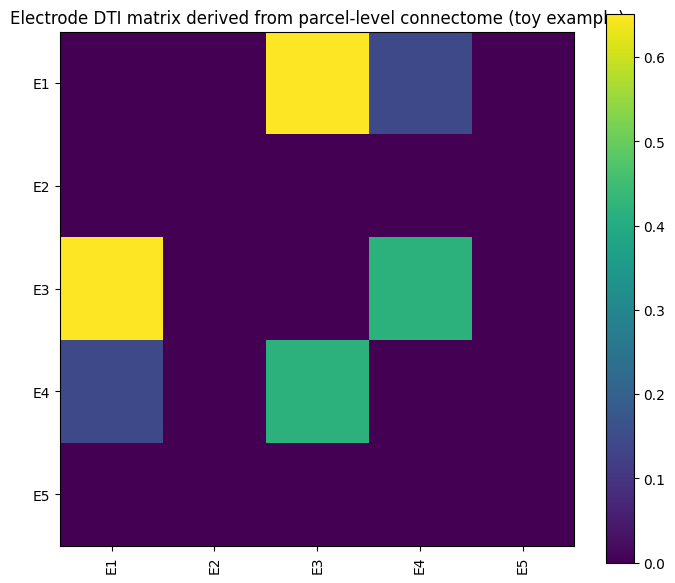

In [ ]:
# TOY EXAMPLE ONLY
# Replace this with a real parcel-level structural connectivity matrix.
n_parcels = len(atlas_labels)
rng = np.random.default_rng(0)
parcel_struct_conn = rng.random((n_parcels, n_parcels))
parcel_struct_conn = (parcel_struct_conn + parcel_struct_conn.T) / 2
np.fill_diagonal(parcel_struct_conn, 0)

# Build an electrode-level matrix by indexing parcel connectivity
electrode_dti_from_parcels = np.zeros((len(mni_coords), len(mni_coords)))

for i, pid_i in enumerate(parcel_ids):
    for j, pid_j in enumerate(parcel_ids):
        if pid_i == 0 or pid_j == 0:
            electrode_dti_from_parcels[i, j] = np.nan
        else:
            electrode_dti_from_parcels[i, j] = parcel_struct_conn[pid_i, pid_j]

plot_matrix(
    np.nan_to_num(electrode_dti_from_parcels, nan=0.0),
    labels=electrode_names,
    title="Electrode DTI matrix derived from parcel-level connectome (toy example)",
    cmap="viridis"
)

## 6. Recommended student workflow

For an introductory project, a very reasonable path is:

### Week 1: rs-fMRI
- start with MNI coordinates
- extract sphere time series
- compute a correlation matrix
- visualize and save the result

### Week 2: atlas mapping
- assign each electrode to an atlas parcel
- verify that each coordinate lands where you expect

### Week 3+: DTI
- either:
  - obtain a parcel-level structural connectome and lift it to electrodes, or
  - obtain a tractogram and build a direct electrode-level matrix from spherical ROIs

This progression helps the student understand the geometry first, then functional connectivity, then structural connectivity.


## 7. Common pitfalls

1. **Space mismatch**  
   MNI coordinates will not work correctly on subject-space images unless you transform them.

2. **Sphere too small or too large**  
   A radius of 4-6 mm is a common starting point, but it depends on voxel size and the scientific question.

3. **Missing atlas labels**  
   Some coordinates may land in background or white matter; check this explicitly.

4. **Different structural and functional data sources**  
   If rs-fMRI and DTI come from different sources or populations, the two matrices are still useful, but they do not represent the same individual.

5. **Interpreting zeros in DTI**  
   A zero in a streamline-count matrix may mean no detected tract, but it can also reflect tractography limitations.


## 8. Suggested extensions

Once the basic notebook works, the student could add:

- **partial correlation** for rs-fMRI
- **Fisher z-transform** for correlations
- **distance correction** (e.g., compare connectivity vs Euclidean distance)
- **thresholding / sparsification**
- **group averaging** across multiple subjects
- **visual comparison of rs-fMRI vs DTI matrices**
- **nearest-neighbor fallback** when an electrode lands outside an atlas parcel


## 9. Minimal summary

At the end of this notebook, the student should be able to answer:

- How do I go from `N x 3` MNI coordinates to an `N x N` rs-fMRI matrix?
- How do I go from those same coordinates to an `N x N` structural matrix?
- What assumptions am I making about spatial alignment and the underlying dataset?

Those are exactly the right first questions for a beginner project like this.
